---
---

# **Employee Attrition Analysis**  
*Authored by Sean Kafka Adhyaksa*

---
---

This project explores the factors associated with employee attrition across 1,470 employee records in order to identify practical and focused retention priorities.

The dataset was created by Mark Bradbourne and published on Data World. Although it is synthetic, it was designed to resemble a realistic HR dataset, so it is still useful for pattern exploration and business-oriented analysis.

**Key Findings**  
1. The overall attrition rate is **16.1%**, which means roughly **1 in 6 employees** left the company. Employee exits also appear to cluster toward the end of the observed period, with the highest count recorded in **April 2022**.  

2. The clearest attrition pattern appears among employees who are **younger, single, in the early stage of tenure, earning less, and working in roles with heavier day-to-day demands**, especially when combined with **overtime** and frequent **business travel**.  

3. The most consistent signals are not formal performance measures, but a combination of **career stage, role pressure, compensation value, and employee experience**, including overtime, job role, job level, tenure, income, stock options, and satisfaction-related variables.

**Recommendations**  
1. Prioritize retention efforts for **higher-risk early-career employees**, especially younger employees, short-tenure employees, and frontline roles such as *Sales Representative*, *Laboratory Technician*, and *Human Resources*.  

2. Reduce the most visible sources of work strain, especially **chronic overtime**, overly frequent travel demands, and a weak early employment experience during the first few years.  

3. Strengthen employees' sense of long-term value through a clearer **career path, more competitive early compensation, meaningful long-term benefits, and targeted improvements in everyday work experience**.

**Employee Attrition Dashboard**  
[Streamlit](https://employee-attrition-db.streamlit.app)

---
# **Introduction**
---

## **Case Scenario**

A company is preparing its year-end HR report and has recorded a noticeable number of employee exits through both resignation and termination. Management wants to understand the pattern behind these exits so that retention efforts for the following year can be planned more effectively.

The HR team needs analytical support to make sense of the existing HR data and answer several important questions about which factors may be associated with attrition.

The main focus of this project is to examine attrition from multiple angles, including employee profile, job characteristics, work pattern, compensation, and workplace experience, so the final recommendations are grounded in evidence rather than assumption.

## **Problem Statement**

The company wants to reduce employee attrition, but HR still needs a clearer picture of **which employee groups leave more often, which roles or departments are under the most pressure, and which workplace conditions are most consistently associated with attrition**.

To address that business need, the analysis is organized around the following questions:

1. How large is the attrition issue, and what pattern appears in the recorded exit timeline?

2. What kind of employee profile appears most often among those who leave?

3. Which departments and job roles show the highest attrition risk?

4. Do work pattern variables such as overtime, travel intensity, and commuting distance relate to attrition?

5. How do compensation, tenure, and satisfaction differ between employees who leave and those who stay?

6. Based on the observed evidence, what should HR prioritize first?

---
# **Dataset Overview**
---

- **Dataset**: `HR_Attrition.csv`

- **Number of Rows**: 1,470

- **Author**: Mark Bradbourne

- **Source**: [Data World - RWFD Real World Fake Data Season 2](https://data.world/markbradbourne/rwfd-real-world-fake-data-season-2/workspace/file?filename=HR_Attrition.csv)

**Data Dictionary**

| Column Name | Data Type | Description |
|---|---|---|
| Attrition Date | Date / Nullable | Date when the employee left the company. Blank if the employee did not leave. |
| Random Number | Integer | Synthetic/randomized numeric field included in the dataset used for fake-data generation or anonymization context. |
| Age | Integer | Employee age in years. |
| Attrition | Categorical | Indicates whether the employee left the company. |
| BusinessTravel | Categorical | Frequency of business travel required for the employee's role. |
| DailyRate | Integer | Employee daily pay rate. |
| Department | Categorical | Department where the employee works. |
| DistanceFromHome | Integer | Distance from employee's home to workplace. |
| Education | Categorical | Highest education level attained by the employee. |
| EducationField | Categorical | Academic field of study of the employee. |
| EmployeeCount | Integer | Count of employee records. |
| EmployeeNumber | Integer | Unique employee identifier. |
| EnvironmentSatisfaction | Integer (Ordinal) | Employee satisfaction with work environment. Higher values indicate greater satisfaction. |
| Gender | Categorical | Employee gender. |
| HourlyRate | Integer | Employee hourly pay rate. |
| JobInvolvement | Integer (Ordinal) | Employee involvement level in their job. Higher values indicate stronger involvement. |
| JobLevel | Integer (Ordinal) | Employee job seniority level. |
| JobRole | Categorical | Specific job title or role of the employee. |
| JobSatisfaction | Integer (Ordinal) | Employee satisfaction with their job. Higher values indicate greater satisfaction. |
| MaritalStatus | Categorical | Employee marital status. |
| MonthlyIncome | Integer | Employee monthly income. |
| MonthlyRate | Integer | Monthly pay rate or billing-related rate recorded in the dataset. |
| NumCompaniesWorked | Integer | Number of companies the employee has worked at before or including current career history context. |
| Over18 | Categorical | Indicates whether employee is over 18 years old. |
| OverTime | Categorical | Indicates whether the employee works overtime. |
| PercentSalaryHike | Integer | Percentage increase in salary. |
| PerformanceRating | Integer (Ordinal) | Employee performance evaluation rating. |
| RelationshipSatisfaction | Integer (Ordinal) | Employee satisfaction with workplace relationships. Higher values indicate greater satisfaction. |
| StandardHours | Integer | Standard working hours value recorded in the dataset. |
| StockOptionLevel | Integer (Ordinal) | Level of stock options granted to the employee. |
| TotalWorkingYears | Integer | Total years of professional working experience. |
| TrainingTimesLastYear | Integer | Number of training sessions attended during the last year. |
| WorkLifeBalance | Integer (Ordinal) | Employee perception of work-life balance. Higher values indicate better balance. |
| YearsAtCompany | Integer | Number of years the employee has worked at the company. |
| YearsInCurrentRole | Integer | Number of years the employee has spent in their current role. |
| YearsSinceLastPromotion | Integer | Number of years since the employee's last promotion. |
| YearsWithCurrManager | Integer | Number of years the employee has worked with their current manager. |

---
# **Importing Libraries**
---

In [1]:
# for data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# statistical tools
import pingouin as pg
from scipy.stats import chi2_contingency

# misc
import warnings
warnings.filterwarnings("ignore")

---
# **Data Preparation**
---

## **Data Loading**

In [2]:
# read dataset file
df = pd.read_csv('../dataset/HR_Attrition.csv')

In [3]:
# display DataFrame
df

,Attrition Date,Random Number,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,4/30/2022 12:00:00 AM,26.0,41,Yes,Travel_Rarely,1102,Sales,1,Associates Degree,Life Sciences,...,1,80,0,8,0,1,6,4,0,5
1,NaN,121.0,49,No,Travel_Frequently,279,Research & Development,8,High School,Life Sciences,...,4,80,1,10,3,3,10,7,1,7
2,5/3/2022 12:00:00 AM,23.0,37,Yes,Travel_Rarely,1373,Research & Development,2,Associates Degree,Other,...,2,80,0,7,3,3,0,0,0,0
3,NaN,56.0,33,No,Travel_Frequently,1392,Research & Development,3,Master's Degree,Life Sciences,...,3,80,0,8,3,3,8,7,3,0
4,NaN,27.0,27,No,Travel_Rarely,591,Research & Development,2,High School,Medical,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,9/2/2021 12:00:00 AM,266.0,34,Yes,Non-Travel,967,Research & Development,16,Master's Degree,Technical Degree,...,2,80,1,5,2,3,5,2,3,0
1466,7/1/2021 12:00:00 AM,329.0,29,Yes,Travel_Frequently,459,Research & Development,24,Associates Degree,Life Sciences,...,2,80,0,1,3,2,1,0,1,0
1467,3/10/2022 12:00:00 AM,77.0,35,Yes,Travel_Frequently,880,Sales,12,Master's Degree,Other,...,1,80,0,13,2,4,11,9,6,7
1468,2/11/2022 12:00:00 AM,104.0,23,Yes,Travel_Rarely,427,Sales,7,Bachelor's Degree,Life Sciences,...,2,80,1,3,2,3,3,2,0,2


The dataset contains 1,470 rows and 37 columns. One missing pattern appears immediately in `Attrition Date`, but this is expected because only employees who left the company have an exit date recorded.

---

## **Checking Data Duplicates**

In [4]:
# duplicated rows
df.duplicated().sum()

0

No duplicated rows were found, which means the dataset represents 1,470 distinct employee records.

---

## **Checking Data Type**

In [5]:
# display dtypes in DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition Date            237 non-null    object 
 1   Random Number             1470 non-null   float64
 2   Age                       1470 non-null   int64  
 3   Attrition                 1470 non-null   object 
 4   BusinessTravel            1470 non-null   object 
 5   DailyRate                 1470 non-null   int64  
 6   Department                1470 non-null   object 
 7   DistanceFromHome          1470 non-null   int64  
 8   Education                 1470 non-null   object 
 9   EducationField            1470 non-null   object 
 10  EmployeeCount             1470 non-null   int64  
 11  EmployeeNumber            1470 non-null   int64  
 12  EnvironmentSatisfaction   1470 non-null   int64  
 13  Gender                    1470 non-null   object 
 14  HourlyRa

The data types are already fairly clean. Most numeric variables are stored as `int64`, there is one `float64` column (`Random Number`), and the categorical fields are stored as `object`.

Referring back to the table above, `Random Number` appears to be a synthetic field with no HR meaning. Therefore, it is safe to assume the irrelevance of this column, thereby discarded in this analysis.

One column still needs adjustment before analysis: `Attrition Date` is currently stored as `object`, even though it represents a date. Since this field will be used to examine the timing of employee exits, converting it to `datetime` makes the later time-based analysis more reliable and easier to handle.

Several score-based variables such as `EnvironmentSatisfaction`, `JobSatisfaction`, `WorkLifeBalance`, and `JobInvolvement` are stored as numbers. Even though these are ordinal in meaning, keeping them in numeric form is still useful for non-parametric testing and distribution-based exploration.

In [6]:
# drop irrelevant column
df.drop(columns=['Random Number'], inplace=True)

# change to datetime format
df['Attrition Date'] = pd.to_datetime(df['Attrition Date'])

---

## **Checking Missing Values**

In [7]:
# check missings in DataFrame
df_mv = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'non_null_values': df.notnull().sum()
})

# only query columns with missing values
df_mv[df_mv['missing_values'] > 0]

,missing_values,non_null_values
Attrition Date,1233,237


`Attrition Date` is missing for most rows because active employees do not have an exit date. In this case, the missing values are expected and should not be treated as a data quality issue. The remaining variables are complete, so the analysis can move forward without major missing-value handling.

---

## **Checking Whitespace**

Whitespace issues can quietly create messy categories, especially in object columns. A minor case example such as `" Bachelor's Degree"` and `"Bachelor's Degree"` would be treated as different categories, even though they mean the same thing.

Because of that, all object columns are checked for leading and trailing whitespace before moving further into the analysis.

In [8]:
print('Checking whitespace:')
# checking lead/trail whitespace char in columns with Dtype: 'object'
for col in df.select_dtypes(include='object').columns:
    any_ws = df[col].astype(str).str.contains(r'^\s|\s$', regex=True).any()

    print(f'Found whitespace in {col}') if any_ws else print(f'No lead/trail whitespace in {col}') 

Checking whitespace:
No lead/trail whitespace in Attrition
No lead/trail whitespace in BusinessTravel
No lead/trail whitespace in Department
No lead/trail whitespace in Education
No lead/trail whitespace in EducationField
No lead/trail whitespace in Gender
No lead/trail whitespace in JobRole
No lead/trail whitespace in MaritalStatus
No lead/trail whitespace in Over18
No lead/trail whitespace in OverTime


No leading or trailing whitespace was found in any object column. This means the categorical values are already written consistently and there is no risk of creating duplicate categories because of hidden spacing.

With that confirmed, no additional string cleaning is needed at this stage.

---

## **Checking Zero Variance Columns**

A zero-variance column contains the same value in every row. Columns like this do not help separate one employee from another, so they add size to the dataset without adding real analytical value.

Before exploring attrition patterns, these columns need to be identified and removed if they are not informative.

In [9]:
# query singular value columns
unique = df.nunique()
unique[unique == 1]

EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64

In [10]:
# sanity check
df[['EmployeeCount', 'Over18', 'StandardHours']]

,EmployeeCount,Over18,StandardHours
0,1,Y,80
1,1,Y,80
2,1,Y,80
3,1,Y,80
4,1,Y,80
...,...,...,...
1465,1,Y,80
1466,1,Y,80
1467,1,Y,80
1468,1,Y,80


Three columns contain only a single value across the full dataset: `EmployeeCount`, `Over18`, and `StandardHours`. Since none of them vary across employees, they cannot help explain attrition.

- `EmployeeCount` is always 1  
- `Over18` is always `Y`  
- `StandardHours` is always 80  

These columns can be removed safely because they do not contribute any meaningful distinction between employees.

In [11]:
# drop redundant columns
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

---

## **Checking High Cardinality Identifier Columns**

High-cardinality columns need a different kind of caution. A column can look informative simply because it has many unique values, but that does not mean it is analytically useful. In HR data, this often happens with identifier-like fields.

At this stage, the goal is to separate columns that describe employee conditions from columns that only label individual records.

In [12]:
# columns with unique values same as length of rows
df.nunique()[df.nunique() == len(df)]

EmployeeNumber    1470
dtype: int64

In [13]:
# sanity check
df[['EmployeeNumber']]

,EmployeeNumber
0,1
1,2
2,4
3,5
4,7
...,...
1465,1905
1466,1868
1467,1667
1468,1702


The dataset also includes fields that behave more like identifiers than explanatory variables. `EmployeeNumber` is a unique employee ID.

This column is removed during cleaning because it does not represent employee behavior or working conditions.

In [14]:
# drop identifier column
df.drop(columns=['EmployeeNumber'], inplace=True)

---

## **Checking Outlier Data**

Investigating outlier is not used here as a reason to remove rows automatically. The main purpose is to understand whether any values look unreasonable or whether they simply reflect natural variation in employee profiles.

The detection method is adjusted to the distribution shape. Variables that are closer to normal are checked with mean ± 3 standard deviations, while skewed variables are checked with a more flexible IQR-based boundary.

In [15]:
def skewness_outliers(dataframe):
    '''
    This function takes in a DataFrame and returns a new DataFrame
    with skewness and outlier information for each numerical column,
    which includes:
        skewness, distribution type, upper and lower boundaries,
        outlier count, and outlier percentage.
    '''
    num_cols = list(dataframe.select_dtypes(np.number).columns)

    list_item = []

    for col in num_cols:
        # detect skewness and distribution type
        skew_val = round(dataframe[col].skew(), 2)
        if -0.5 <= skew_val <= 0.5:
            dist_type = 'normal'
        elif -1 <= skew_val <= -0.5 or 0.5 <= skew_val <= 1:
            dist_type = 'moderately skewed'
        else:
            dist_type = 'highly skewed'

        # upper and lower boundaries for normal and skewed data
        if dist_type == 'normal':
            lower_boundary = (dataframe[col].mean() - 3 * dataframe[col].std()).round(2)
            upper_boundary = (dataframe[col].mean() + 3 * dataframe[col].std()).round(2)

        else:
            IQR = dataframe[col].quantile(0.75) - dataframe[col].quantile(0.25)
            lower_boundary = (dataframe[col].quantile(0.25) - (IQR * 3)).round(2)
            upper_boundary = (dataframe[col].quantile(0.75) + (IQR * 3)).round(2)
        
        # outlier count and percentage
        outlier_count = len(dataframe[(dataframe[col] > upper_boundary) | (dataframe[col] < lower_boundary)])
        outlier_pct = round((outlier_count / len(dataframe)) * 100, 2)

        # adding the findings to list_item empty list
        list_item.append([
            col,
            skew_val, dist_type,
            lower_boundary, upper_boundary,
            outlier_count, outlier_pct
        ])

    # create DataFrame
    skewness_outliers = pd.DataFrame(
        list_item,
        columns=[
            'column_label',
            'skewness', 'distribution',
            'lower_boundary', 'upper_boundary',
            'outlier_count', 'outlier%'
        ])

    # returns new DataFrame    
    return skewness_outliers

In [16]:
# display skewed data with potential outliers
skewness_outliers_df = skewness_outliers(df)

skewness_outliers_df[skewness_outliers_df['distribution'] != 'normal'].sort_values(by='distribution', ascending=True)

,column_label,skewness,distribution,lower_boundary,upper_boundary,outlier_count,outlier%
6,JobLevel,1.03,highly skewed,-5.0,9.0,0,0.00
8,MonthlyIncome,1.37,highly skewed,-13493.0,24783.0,0,0.00
10,NumCompaniesWorked,1.03,highly skewed,-8.0,13.0,0,0.00
12,PerformanceRating,1.92,highly skewed,3.0,3.0,226,15.37
15,TotalWorkingYears,1.12,highly skewed,-21.0,42.0,0,0.00
18,YearsAtCompany,1.76,highly skewed,-15.0,27.0,19,1.29
20,YearsSinceLastPromotion,1.98,highly skewed,-9.0,12.0,32,2.18
2,DistanceFromHome,0.96,moderately skewed,-34.0,50.0,0,0.00
11,PercentSalaryHike,0.82,moderately skewed,-6.0,36.0,0,0.00
14,StockOptionLevel,0.97,moderately skewed,-3.0,4.0,0,0.00


Most numeric variables do not show outliers that look suspicious from an HR perspective. A few columns fall outside the statistical boundaries, such as `PerformanceRating`, `YearsAtCompany`, and `YearsSinceLastPromotion`, but those values still make sense in context. In employee data, long tenure, long promotion gaps, or compressed performance ratings can happen naturally.

For that reason, these points are treated as part of the employee profile variation rather than as input errors. No rows are removed, so the later analysis can still capture patterns that happen at the more extreme ends of the workforce.

In [17]:
# display normally distributed data
skewness_outliers_df[skewness_outliers_df['distribution'] == 'normal']

,column_label,skewness,distribution,lower_boundary,upper_boundary,outlier_count,outlier%
0,Age,0.41,normal,9.52,64.33,0,0.0
1,DailyRate,-0.00,normal,-408.04,2013.01,0,0.0
3,EnvironmentSatisfaction,-0.32,normal,-0.56,6.00,0,0.0
4,HourlyRate,-0.03,normal,4.90,126.88,0,0.0
5,JobInvolvement,-0.50,normal,0.60,4.86,0,0.0
7,JobSatisfaction,-0.33,normal,-0.58,6.04,0,0.0
9,MonthlyRate,0.02,normal,-7040.25,35666.46,0,0.0
13,RelationshipSatisfaction,-0.30,normal,-0.53,5.96,0,0.0


---

## **Summary: Data Cleaning Report**

Overall, the dataset is in good enough condition to move directly into analysis.

A few important points stand out from the cleaning stage:

- No duplicated rows were found.  
- Missing values only appear in `Attrition Date`, and that pattern is expected because active employees do not have an exit date.  
- No whitespace issues were found in categorical columns.  
- Non-informative columns such as `EmployeeCount`, `Over18`, `StandardHours`, and `Random Number` were removed.  
- Extreme values still look reasonable in business context, so no rows were deleted.

With the structure cleaned and the main data quality checks completed, the next step is to examine attrition itself: how large it is, when exits appear to cluster, and which groups stand out most clearly.

---
# **Exploration & Analysis**
---

## **Inspecting Attrition Pattern**

### **1. Attrition Rate**

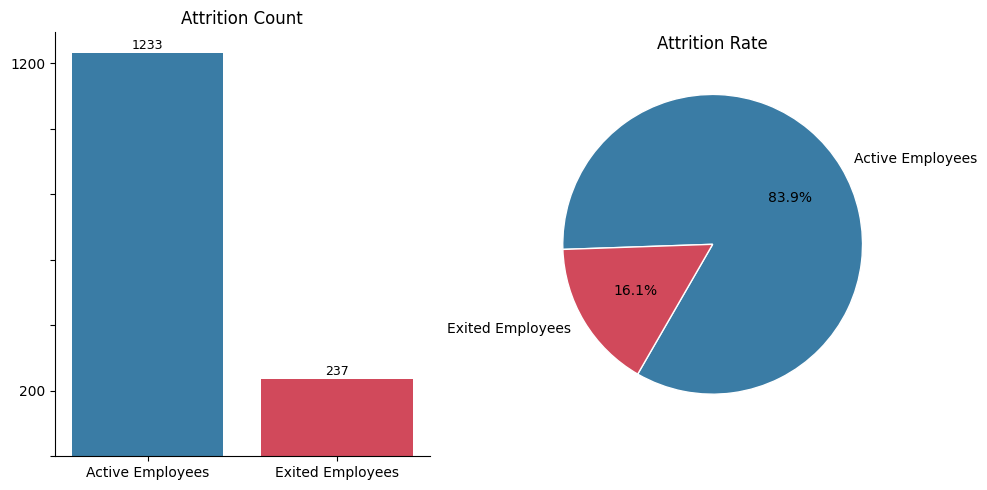

In [18]:
# employee variables
employees_total = len(df)
employees_active = (df['Attrition'] == 'No').sum()
employees_exit = (df['Attrition'] == 'Yes').sum()

# attrition variables
attrition_count = df['Attrition'].value_counts()
attrition_rate = (df['Attrition'] == 'Yes').mean()

# plot visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

#=========================
# Attrition Count Barplot
#=========================
axes[0].bar(
    x=attrition_count.index.map({
        'No': 'Active Employees',
        'Yes': 'Exited Employees'
        }),
    height=attrition_count.values,
    color=['#3A7CA5', '#D1495B']
)
# annotate value center bar
for i, v in enumerate(attrition_count.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

# custom y axis tick marks and labels
yticks = axes[0].get_yticks()
axes[0].set_yticklabels([
    int(tick) if int(tick) in [200, 1200] else '' for tick in yticks
])

# barplot title
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('')

#============================
# Attrition Rate Donut Chart
#============================
axes[1].pie(
    attrition_count.values,
    labels=['Active Employees', 'Exited Employees'],
    autopct='%1.1f%%',
    startangle=240,
    colors=['#3A7CA5', '#D1495B'],
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Attrition Rate')

plt.tight_layout()
plt.show()

Out of **1,470** employees, **237** are recorded as having left the company and **1,233** are still active. This gives an overall attrition rate of **16.1%**.

That is not a minor figure. In practical terms, the company is losing about **1 out of every 6 employees**. For HR, a pattern at this level matters because attrition can affect recruitment cost, onboarding effort, team productivity, and the loss of role-specific knowledge.

This first finding confirms that attrition is a real issue in the dataset. The next question is whether employee exits are spread evenly across time and across employee groups, or whether they concentrate in certain periods and conditions.

### **2. Monthly Attrition Trend**

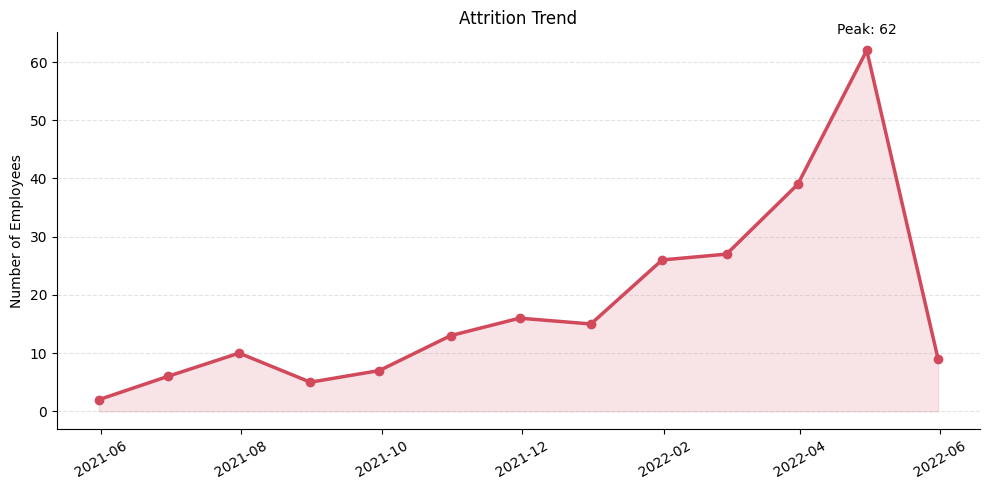

In [19]:
# query exited employees DataFrame
df_attrition = df[df['Attrition'] == 'Yes']

# aggregate monthly by Attrition Date
monthly_attrition = (
    df_attrition
    .set_index('Attrition Date')
    .resample('M')
    .size()
)

# visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_attrition.index, monthly_attrition.values, marker='o', linewidth=2.5, color='#D1495B')
ax.fill_between(monthly_attrition.index, monthly_attrition.values, alpha=0.15, color='#D1495B')

ax.set_title('Attrition Trend')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.set_xlabel('')
ax.set_ylabel('Number of Employees')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate(
    f'Peak: {monthly_attrition.max()}',
    xy=(monthly_attrition.idxmax(), monthly_attrition.max()),
    xytext=(0, 12),
    textcoords='offset points',
    ha='center',
    fontsize=10
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The chart suggests that employee exits become more concentrated toward the later part of the observed period. The highest recorded count appears in **May 2022** with **62 exits**, while the drop in the following month is likely influenced by incomplete recording for the final month.

Because this is a cross-sectional dataset, the timeline should be read as an **observed exit pattern**, not as a formal monthly attrition rate. Even so, it is still informative. Employee exits do not appear evenly distributed over time, and the clustering near the end of the period suggests that attrition pressure may have intensified rather than remained stable.

### **3. Attrition Contributing Factors**

Before moving into more detailed segmentation, it helps to identify which variables show a meaningful statistical association with attrition.

Since the dataset contains a mix of numeric and categorical variables, different tests are used for different data types:

- **Mann-Whitney U test** is used for numeric and ordinal variables because it is more appropriate when normality cannot be assumed.  
- **Chi-square test** is used for categorical variables to check whether the distribution differs across attrition groups.  
- **Effect size** is then reviewed to see how strong the relationship actually is, so the interpretation does not stop at whether something is statistically significant.

This section acts as a bridge between descriptive exploration and deeper interpretation. It helps narrow the focus toward the variables that deserve closer attention in the business discussion.

In [20]:
def cramers_v(confusion_matrix):
    '''
    Calculate Cramer's V statistic for measuring association 
    between two categorical variables based on the Chi-square 
    test and provides a value between 0 and 1:
    - 0 = no association between variables
    - 1 = perfect association
    '''
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

results = []
target = 'Attrition'

# loop all cols except datetime
for col in df.drop(columns=['Attrition Date']).columns:
    if col == target:
        continue

    if df[col].dtype != 'object':
        # Pingouin library used for num columns
        # Mann-Whitney U test used for dependency test, then
        # Rank biserial r for effect size  
        group1 = df[df[target] == 'Yes'][col]
        group2 = df[df[target] == 'No'][col]

        res = pg.mwu(group1, group2)
                
        results.append([
            col,
            'numeric',
            'Mann-Whitney U',
            res['p-val'].values[0],
            'Rank-biserial',
            res['RBC'].values[0]
        ])

    else:
        # manual scipy.stats for cat columns
        # Chi-squared test for dependency, then
        # Cramer's V for effect size
        contingency = pd.crosstab(df[col], df[target])
        chi2, p, _, _ = chi2_contingency(contingency)
        v = cramers_v(contingency)

        results.append([
            col,
            'categorical',
            'Chi-square',
            p,
            "Cramér's V",
            v
        ])

attrition_factors = pd.DataFrame(results, columns=[
    'Feature', 'Data Type', 'Test', 'p-value', 'Effect Size Test', 'Effect Size'
])

print(f'{len(attrition_factors)} Features have been statistically tested.')

30 Features have been statistically tested.


#### **a. Statistically significant factors**

In [21]:
# statistically significant
attrition_factors[attrition_factors['p-value'] < 0.05]

,Feature,Data Type,Test,p-value,Effect Size Test,Effect Size
0,Age,numeric,Mann-Whitney U,5.304342e-11,Rank-biserial,-0.268643
1,BusinessTravel,categorical,Chi-square,5.608614e-06,Cramér's V,0.128260
2,DailyRate,numeric,Mann-Whitney U,2.900458e-02,Rank-biserial,-0.089443
3,Department,categorical,Chi-square,4.525607e-03,Cramér's V,0.085698
4,DistanceFromHome,numeric,Mann-Whitney U,2.387047e-03,Rank-biserial,0.123982
6,EducationField,categorical,Chi-square,6.773980e-03,Cramér's V,0.104409
7,EnvironmentSatisfaction,numeric,Mann-Whitney U,2.173049e-04,Rank-biserial,-0.145941
10,JobInvolvement,numeric,Mann-Whitney U,4.651927e-06,Rank-biserial,-0.165310
11,JobLevel,numeric,Mann-Whitney U,2.956987e-13,Rank-biserial,-0.283217
12,JobRole,categorical,Chi-square,2.752482e-15,Cramér's V,0.242142


Out of 30 tested features, 21 show a statistically significant difference between employees who left and those who stayed. This means a fairly large share of the dataset contains patterns that differ across the two groups.

Still, statistical significance should be read carefully. A significant result does not mean a variable directly causes attrition. It only shows that the pattern is unlikely to be random within this dataset.

Because of that, this table works best as an early filter. It highlights which factors are worth examining further, while the next step, effect size, helps separate variables with a more visible relationship from those whose impact is statistically detectable but practically small.

#### **b. Positive effect size**

In [22]:
# statistically significant where p-value < 0.05
attrition_effect = attrition_factors[attrition_factors['p-value'] < 0.05]

# positive effect size
# the higher the stronger effect towards attrition decision
attrition_effect[attrition_effect['Effect Size'] >= 0].sort_values(by='Effect Size', ascending=False)

,Feature,Data Type,Test,p-value,Effect Size Test,Effect Size
18,OverTime,categorical,Chi-square,8.158424e-21,Cramér's V,0.244065
12,JobRole,categorical,Chi-square,2.752482e-15,Cramér's V,0.242142
14,MaritalStatus,categorical,Chi-square,9.455511e-11,Cramér's V,0.177211
1,BusinessTravel,categorical,Chi-square,5.608614e-06,Cramér's V,0.128260
4,DistanceFromHome,numeric,Mann-Whitney U,2.387047e-03,Rank-biserial,0.123982
6,EducationField,categorical,Chi-square,6.773980e-03,Cramér's V,0.104409
3,Department,categorical,Chi-square,4.525607e-03,Cramér's V,0.085698


The variables with positive effect size are largely tied to **working conditions and job structure**. The most prominent examples are `OverTime`, `JobRole`, `MaritalStatus`, and `BusinessTravel`, followed by variables such as `DistanceFromHome`, `EducationField`, and `Department`.

Among them, `OverTime` and `JobRole` stand out as the strongest categorical signals. This suggests that attrition is closely related to how the job is experienced in practice, not just to employee background.

One numeric variable that appears in this group is `DistanceFromHome`. The direction suggests that longer commuting distance is associated with higher attrition risk. From a behavioral point of view, that is reasonable, because commuting burden can accumulate as a daily source of fatigue, especially when paired with overtime or frequent travel.

`EducationField` and `Department` also matter, but their effect sizes are smaller. They seem more like supporting context than central drivers.

Taken together, this pattern points to a general idea that attrition appears to be shaped more by workload, role demand, and everyday operational pressure than by stable personal traits alone.

#### **c. Negative effect size**

In [23]:
# the higher the less chance towards attrition decision
attrition_effect[attrition_effect['Effect Size'] < 0].sort_values(by='Effect Size', ascending=True)

,Feature,Data Type,Test,p-value,Effect Size Test,Effect Size
23,TotalWorkingYears,numeric,Mann-Whitney U,2.399569e-14,Rank-biserial,-0.311706
15,MonthlyIncome,numeric,Mann-Whitney U,2.950831e-14,Rank-biserial,-0.311340
26,YearsAtCompany,numeric,Mann-Whitney U,2.916191e-13,Rank-biserial,-0.297915
11,JobLevel,numeric,Mann-Whitney U,2.956987e-13,Rank-biserial,-0.283217
27,YearsInCurrentRole,numeric,Mann-Whitney U,4.429560e-12,Rank-biserial,-0.279901
29,YearsWithCurrManager,numeric,Mann-Whitney U,1.806754e-11,Rank-biserial,-0.272048
0,Age,numeric,Mann-Whitney U,5.304342e-11,Rank-biserial,-0.268643
22,StockOptionLevel,numeric,Mann-Whitney U,4.013375e-11,Rank-biserial,-0.249808
10,JobInvolvement,numeric,Mann-Whitney U,4.651927e-06,Rank-biserial,-0.165310
13,JobSatisfaction,numeric,Mann-Whitney U,7.957918e-05,Rank-biserial,-0.155690


The variables with negative effect size mostly describe **career maturity, organizational attachment, and accumulated value inside the company**. The clearest examples are `TotalWorkingYears`, `MonthlyIncome`, `YearsAtCompany`, `JobLevel`, `YearsInCurrentRole`, and related tenure-based measures.

The direction here suggests that attrition tends to become lower as employees move further into their career, earn more, hold more senior roles, and spend longer in the company or in the same role. In other words, employees who are already more established appear less likely to leave.

This does not mean tenure or income directly protect every employee from attrition. A more careful interpretation is that employees who stay longer often gain stronger organizational fit, clearer career positioning, and more to lose by exiting. That makes these variables useful for identifying where vulnerability is highest: closer to the early-career and lower-level end of the workforce.

#### **d. Statistically insignificant factors**

In [24]:
# statistically insignificant where p-value > 0.05
attrition_factors[attrition_factors['p-value'] >= 0.05]

,Feature,Data Type,Test,p-value,Effect Size Test,Effect Size
5,Education,categorical,Chi-square,0.545525,Cramér's V,0.045729
8,Gender,categorical,Chi-square,0.290572,Cramér's V,0.027565
9,HourlyRate,numeric,Mann-Whitney U,0.797630,Rank-biserial,-0.010506
16,MonthlyRate,numeric,Mann-Whitney U,0.558748,Rank-biserial,0.023954
17,NumCompaniesWorked,numeric,Mann-Whitney U,0.242365,Rank-biserial,0.046670
19,PercentSalaryHike,numeric,Mann-Whitney U,0.365515,Rank-biserial,-0.036849
20,PerformanceRating,numeric,Mann-Whitney U,0.911945,Rank-biserial,0.002833
21,RelationshipSatisfaction,numeric,Mann-Whitney U,0.102025,Rank-biserial,-0.064554


Several variables do not show a statistically significant relationship with attrition, including `Education`, `Gender`, `HourlyRate`, `MonthlyRate`, `PercentSalaryHike`, `PerformanceRating`, and `RelationshipSatisfaction`.

This is useful because it helps narrow the story. Attrition in this dataset does **not** appear to be strongly separated by broad demographic traits such as gender or by formal education level. It also does not seem to be meaningfully explained by `PerformanceRating`, which suggests that employees who leave are not simply the lowest performers.

A similar point applies to `PercentSalaryHike`. Annual salary increase, at least in the form captured by this variable, does not strongly distinguish the employees who leave from those who stay. That hints that attrition may be more sensitive to **career stage, job pressure, overall compensation value, and everyday work experience** than to a routine percentage increase alone.

### **Summary**

The statistical results reinforce a clear pattern: attrition in this dataset is more strongly associated with **career stage, job pressure, and work conditions** than with formal performance measures.

The most relevant signals appear around:
- overtime  
- job role  
- tenure and total work experience  
- job level  
- income  
- stock options  
- and several job satisfaction indicators  

This gives a useful foundation for the rest of the analysis. The next sections move from broad statistical screening into a more concrete profile of who is at risk and under which conditions attrition becomes more visible.

---

## **At Risk Employees**

### **1. Individual Profile**

To make the employee profile easier to read, several variables are grouped into broader categories. This allows the attrition pattern to be compared across age, gender, and marital status without getting lost in too many small segments.

In [25]:
# create new derivative columns 
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 55, 65],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65']
)

# Create new interpretable target label column
df['AttritionLabel'] = df['Attrition'].map({
    'Yes': 'Exited Employees',
    'No': 'Active Employees'
})

# column variables
personal_cols = ['AgeGroup', 'Gender', 'MaritalStatus']

# Styling
colors = {
    'Active Employees': '#3A7CA5',
    'Exited Employees': '#D1495B'
}

The charts below compare the share of active and exited employees within each personal profile category. The dashed line marks the overall attrition rate, which helps show which groups sit clearly above the company-wide level.

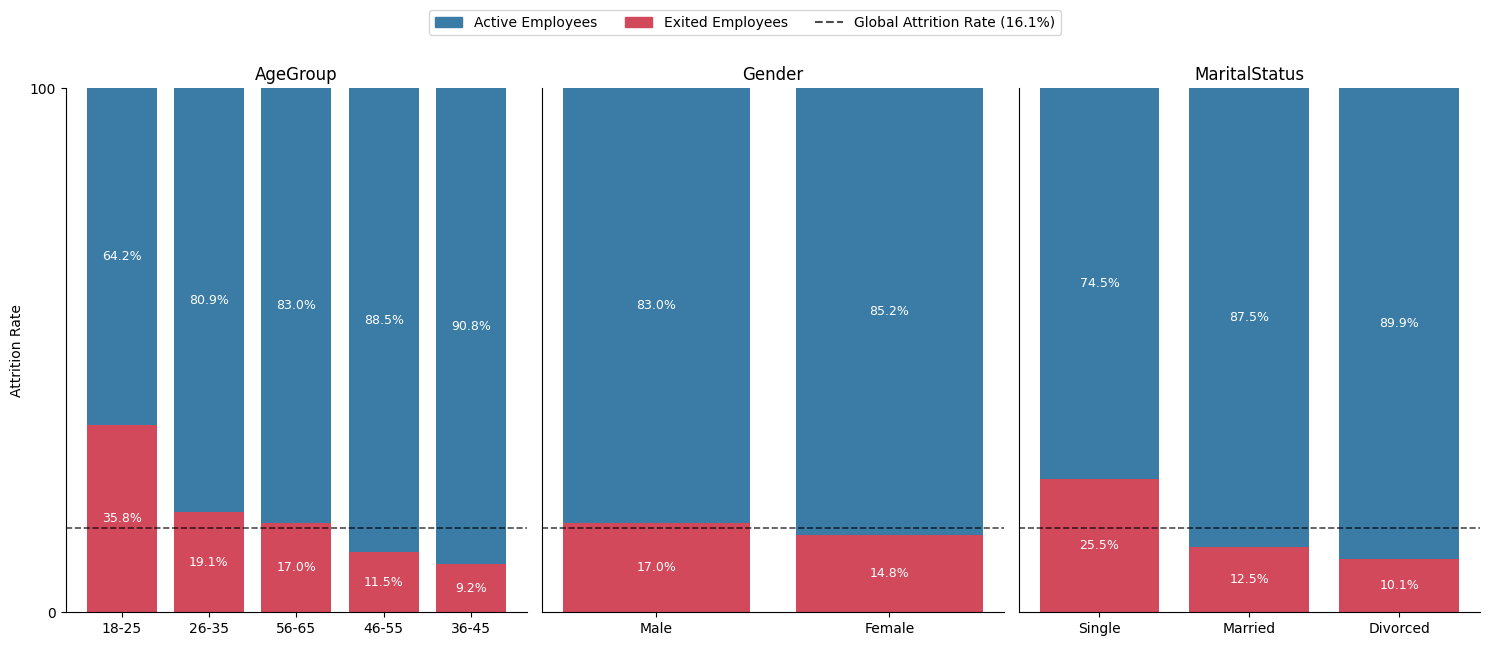

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(personal_cols):
    ax = axes[i]

    # groupby Attrition
    temp = (
        df.groupby([col, 'AttritionLabel'])
          .size()
          .unstack(fill_value=0)
    )
    
    # Convert to percentage, sort descending
    pct = temp.div(temp.sum(axis=1), axis=0) * 100
    pct = pct.sort_values(by='Exited Employees', ascending=False)

    x = range(len(pct))

    # Stacked barplot: Exited at bottom, Active at top
    bars_exited = ax.bar(
        x,
        pct['Exited Employees'],
        color=colors['Exited Employees'],
        label='Exited Employees'
        )
    bars_active = ax.bar(
        x,
        pct['Active Employees'],
        bottom=pct['Exited Employees'],
        color=colors['Active Employees'],
        label='Active Employees'
    )

    # Percentage annotations
    for j, (_, row) in enumerate(pct.iterrows()):
        exited_val = row['Exited Employees']
        active_val = row['Active Employees']

        if exited_val > 0:
            ax.text(
                j, exited_val / 2,
                f'{exited_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )
        if active_val > 0:
            ax.text(
                j, exited_val + (active_val / 2),
                f'{active_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
                )

    # Global attrition threshold line
    ax.axhline(
        y=16.1, color='black', linestyle='--', alpha=0.7, linewidth=1.2,
        label='Global Attrition Rate (16.1%)' if i == 2 else None
        )
    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Axis formatting
    ax.set_title(col)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pct.index, rotation=0)
    ax.set_xlabel('')
    ax.set_ylim(0, 100)

    # Only show y-ticks once at the far left
    if i == 0:
        ax.set_yticks([0, 100])
        ax.set_ylabel('Attrition Rate')
    else:
        ax.set_yticks([0, 100])
        ax.tick_params(axis='y', left=False, labelleft=False)

# legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors['Active Employees']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Exited Employees']),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.7)
    ]
labels = ['Active Employees', 'Exited Employees', 'Global Attrition Rate (16.1%)']

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),     # positioning
    ncol=3                          # flatten horizontal
    )
plt.tight_layout()
plt.show()

Two personal patterns stand out most clearly. First, attrition is highest among employees aged **18-25**, at around **35.8%**, followed by the **26-35** group at **19.1%**. After that, the rate drops notably in older age groups. This makes the early-career phase look especially fragile.

Second, marital status also separates risk quite clearly. Employees who are **single** show attrition of about **25.5%**, well above employees who are **married** (**12.5%**) or **divorced** (**10.1%**). When read in conjunction with age, the pattern feels consistent. Employees who are still in a more exploratory point in life and career stage may be more open to switching jobs when a better option appears.

By contrast, the gap between men and women is relatively small, around **17.0%** versus **14.8%**. This also matches the earlier statistical test, where `Gender` did not appear to be a meaningful differentiator. So within the personal profile, the more useful signals are **younger age and single status**, not gender.

### **2. Career Profile**

A second profile view is built around career-related background, especially education, field of study, and tenure grouping. This helps separate general personal characteristics from variables that are closer to career progression.

In [27]:
# create new derivative columns 
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 1, 3, 5, 10, 40],
    labels=['<=1 year', '2-3 years', '4-5 years', '6-10 years', '10+ years']
)

# column variables
career_cols = ['Education', 'EducationField', 'TenureGroup']

The next set of visuals shows how attrition changes across education level, education field, and tenure stage. Looking at these variables together helps clarify whether the issue is more closely tied to academic background or to position in the career journey.

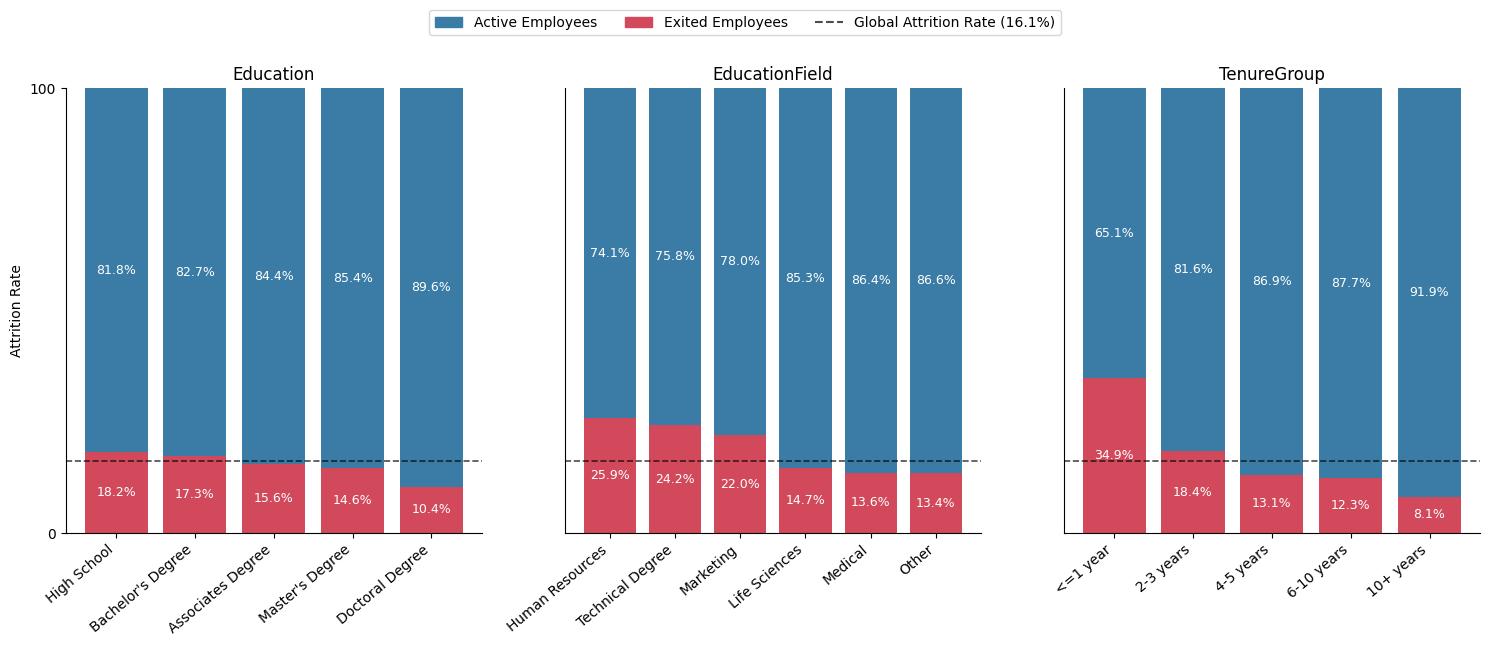

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(career_cols):
    ax = axes[i]

    # groupby Attrition
    temp = (
        df.groupby([col, 'AttritionLabel'])
          .size()
          .unstack(fill_value=0)
    )
    
    # Convert to percentage, sort descending
    pct = temp.div(temp.sum(axis=1), axis=0) * 100
    pct = pct.sort_values(by='Exited Employees', ascending=False)

    x = range(len(pct))

    # Stacked barplot: Exited at bottom, Active at top
    bars_exited = ax.bar(
        x,
        pct['Exited Employees'],
        color=colors['Exited Employees'],
        label='Exited Employees'
    )
    bars_active = ax.bar(
        x,
        pct['Active Employees'],
        bottom=pct['Exited Employees'],
        color=colors['Active Employees'],
        label='Active Employees'
    )

    # Percentage annotations
    for j, (_, row) in enumerate(pct.iterrows()):
        exited_val = row['Exited Employees']
        active_val = row['Active Employees']

        if exited_val > 0:
            ax.text(
                j, exited_val / 2,
                f'{exited_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )
        if active_val > 0:
            ax.text(
                j, exited_val + (active_val / 2),
                f'{active_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

    # Global attrition threshold line
    ax.axhline(
        y=16.1, color='black', linestyle='--', alpha=0.7, linewidth=1.2,
        label='Global Attrition Rate (16.1%)' if i == 2 else None
    )

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Axis formatting
    ax.set_title(col)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pct.index, rotation=40, ha='right')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)

    # Only show y-ticks once at the far left
    if i == 0:
        ax.set_yticks([0, 100])
        ax.set_ylabel('Attrition Rate')
    else:
        ax.set_yticks([0, 100])
        ax.tick_params(axis='y', left=False, labelleft=False)

# legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors['Active Employees']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Exited Employees']),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.7)
]
labels = ['Active Employees', 'Exited Employees', 'Global Attrition Rate (16.1%)']

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3
)

plt.tight_layout()
plt.show()

From the career profile side, the strongest differences do not come from education level in and of itself, but from the **field of study** and **tenure stage**.

`Education` remains fairly stable across categories and was also not statistically significant earlier. `EducationField`, however, shows clearer differences, with relatively high attrition in groups such as **Human Resources (25.9%)**, **Technical Degree (24.2%)**, and **Marketing (22.0%)**.

The tenure pattern is even more striking. Employees in the junior tenure group show attrition around **34.9%**, then the rate drops to **18.4%** in the middle stage and continues downward until it reaches only **8.1%** in the senior group. This suggests that attrition in the dataset happens much more often before employees become fully established in the company.

In practical terms, the challenge does not seem to be about keeping long-tenured employees from leaving. It is more about helping newer employees get through the adaptation period, build commitment, and see a clearer future inside the organization.

### **Summary**

When these profile findings are combined, the higher-risk employee picture becomes fairly clear: attrition is more concentrated among employees who are **younger, single, and still in the early stage of tenure**, especially within the first few years of work.

This matters because attrition is not spread evenly across the workforce. It clusters around a specific life stage and career stage. That means retention efforts are likely to be more effective when focused on **newer and early-career employees**, rather than using a broad and uniform approach for everyone.

---

## **At Risk Job Functions**

#### **Department & Job Role**

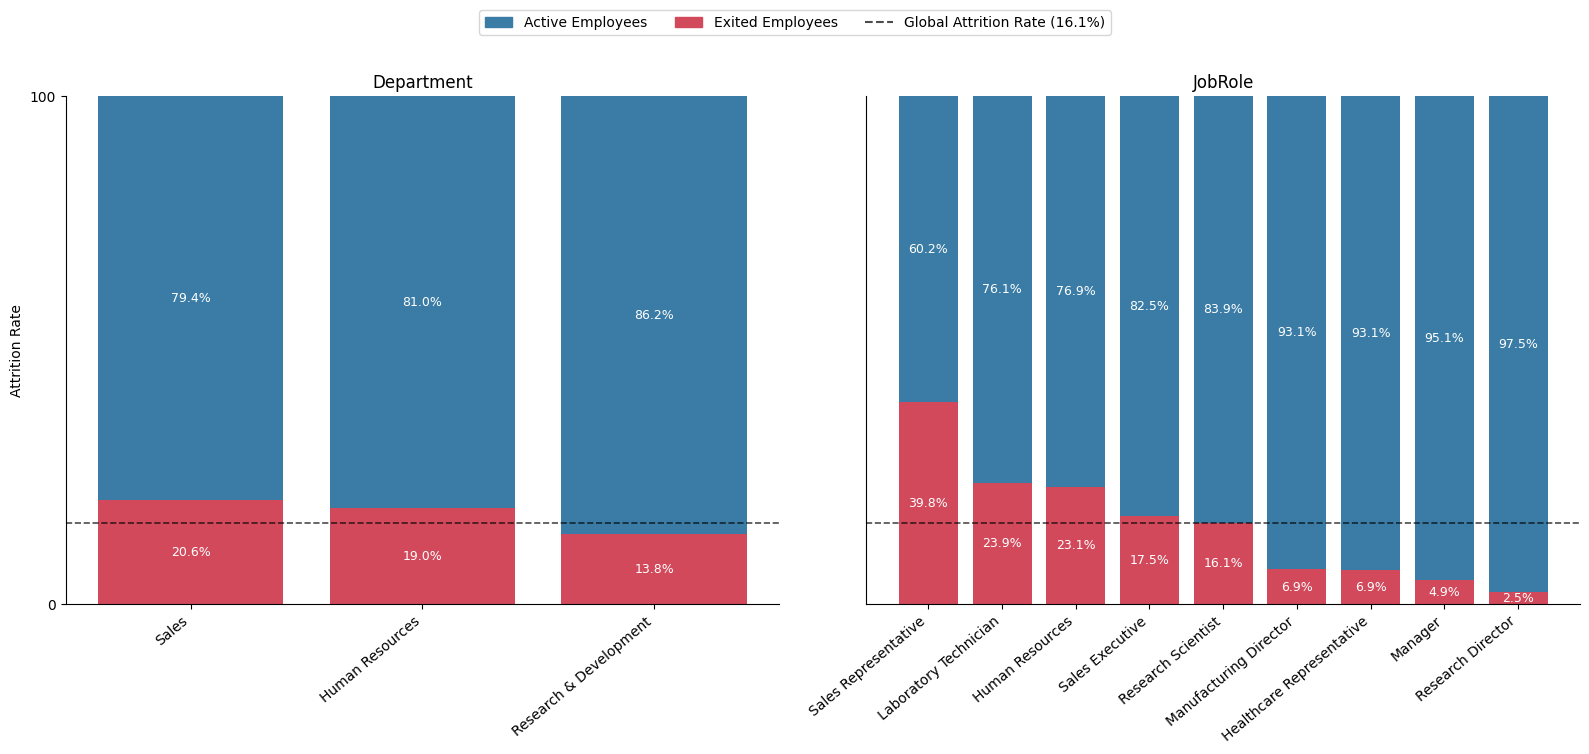

In [29]:
# column variables
job_cols = ['Department', 'JobRole']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, col in enumerate(job_cols):
    ax = axes[i]

    # groupby Attrition
    temp = (
        df.groupby([col, 'AttritionLabel'])
          .size()
          .unstack(fill_value=0)
    )

    # Convert to percentage, sort descending by Exited Employees
    pct = temp.div(temp.sum(axis=1), axis=0) * 100
    pct = pct.sort_values(by='Exited Employees', ascending=False)

    x = range(len(pct))

    # Stacked barplot: Exited at bottom, Active at top
    bars_exited = ax.bar(
        x,
        pct['Exited Employees'],
        color=colors['Exited Employees'],
        label='Exited Employees'
    )
    bars_active = ax.bar(
        x,
        pct['Active Employees'],
        bottom=pct['Exited Employees'],
        color=colors['Active Employees'],
        label='Active Employees'
    )

    # Percentage annotations
    for j, (_, row) in enumerate(pct.iterrows()):
        exited_val = row['Exited Employees']
        active_val = row['Active Employees']

        if exited_val > 0:
            ax.text(
                j, exited_val / 2,
                f'{exited_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

        if active_val > 0:
            ax.text(
                j, exited_val + (active_val / 2),
                f'{active_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

    # Global attrition threshold line
    ax.axhline(
        y=16.1, color='black', linestyle='--', alpha=0.7, linewidth=1.2,
        label='Global Attrition Rate (16.1%)' if i == 1 else None
    )

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Axis formatting
    ax.set_title(col)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pct.index, rotation=40, ha='right')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)

    # Only show y-ticks once at the far left
    if i == 0:
        ax.set_yticks([0, 100])
        ax.set_ylabel('Attrition Rate')
    else:
        ax.set_yticks([0, 100])
        ax.tick_params(axis='y', left=False, labelleft=False)

# legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors['Active Employees']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Exited Employees']),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.7)
]
labels = [
    'Active Employees',
    'Exited Employees',
    'Global Attrition Rate (16.1%)'
]

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3
)

plt.tight_layout()
plt.show()

Moving from employee profile to job structure point of view, `JobRole` creates a much sharper separation than `Department` alone.

At the department level, `Sales` has the highest attrition at about **20.6%**, followed by `Human Resources` at **19.0%**, while `Research & Development` stays below the overall rate at **13.8%**.

The pattern becomes much more distinct at the role level. `Sales Representative` has the highest attrition at about **39.8%**, followed by `Laboratory Technician` (**23.9%**) and `Human Resources` (**23.1%**). On the other side, roles such as `Research Director` (**2.5%**) and `Manager` (**4.9%**) show very low attrition.

This difference matters because attrition is not distributed evenly within departments. A department can look relatively stable on average while still containing one or two roles with much heavier turnover. For that reason, any retention response should be designed at a more specific level than department alone.

### **Summary**

This section makes it clear that **job role is one of the strongest separators of attrition** in the dataset. The company does not seem to be facing one uniform retention problem. Instead, the issue appears concentrated in a limited set of roles.

From a business perspective, that means retention planning should go beyond department labels. HR may need more role-specific action, such as reviewing workload, expectations, incentives, manager support, and career path clarity in the positions that lose people most often.

---

## **Working Conditions and Patterns**

#### **1. Work Pattern**

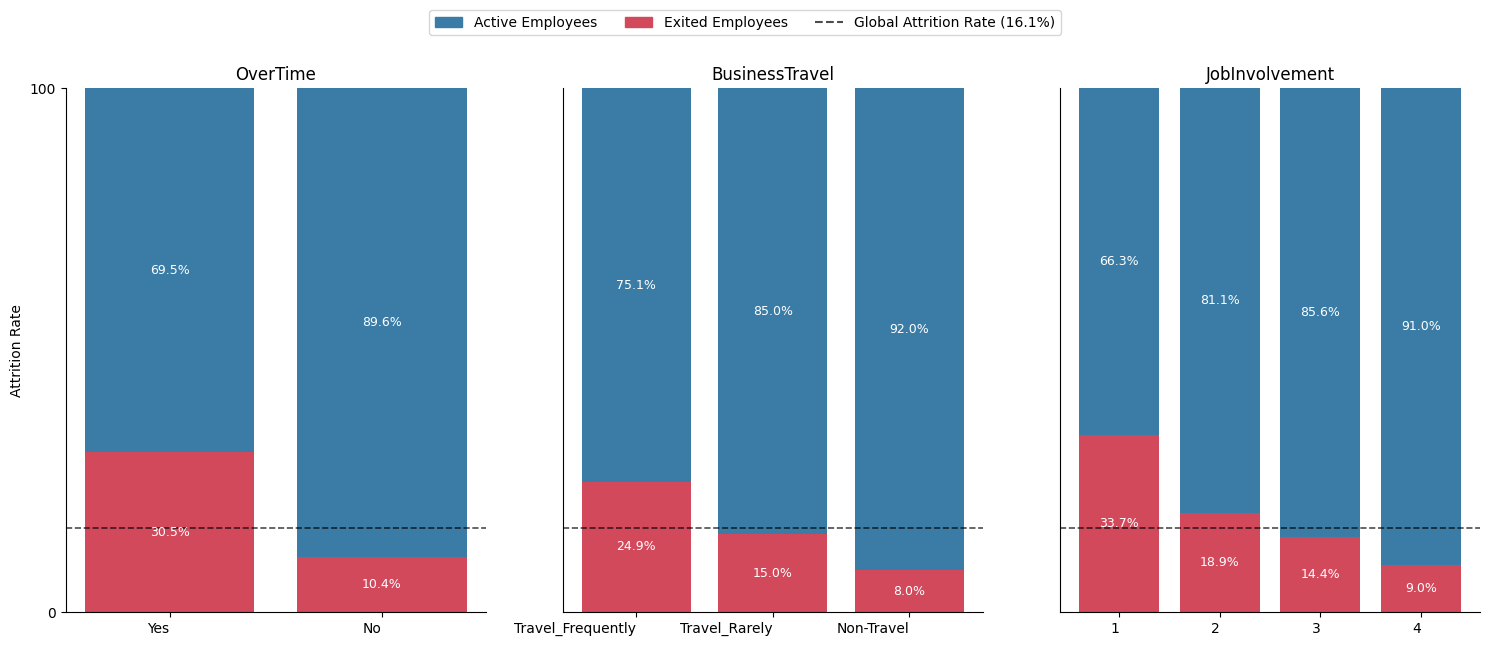

In [30]:
work_pattern_cols = ['OverTime', 'BusinessTravel', 'JobInvolvement']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(work_pattern_cols):
    ax = axes[i]

    # groupby Attrition
    temp = (
        df.groupby([col, 'AttritionLabel'])
          .size()
          .unstack(fill_value=0)
    )

    # Convert to percentage, sort descending by Exited Employees
    pct = temp.div(temp.sum(axis=1), axis=0) * 100
    pct = pct.sort_values(by='Exited Employees', ascending=False)

    x = range(len(pct))

    # Stacked barplot: Exited at bottom, Active at top
    bars_exited = ax.bar(
        x,
        pct['Exited Employees'],
        color=colors['Exited Employees'],
        label='Exited Employees'
    )
    bars_active = ax.bar(
        x,
        pct['Active Employees'],
        bottom=pct['Exited Employees'],
        color=colors['Active Employees'],
        label='Active Employees'
    )

    # Percentage annotations
    for j, (_, row) in enumerate(pct.iterrows()):
        exited_val = row['Exited Employees']
        active_val = row['Active Employees']

        if exited_val > 0:
            ax.text(
                j, exited_val / 2,
                f'{exited_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

        if active_val > 0:
            ax.text(
                j, exited_val + (active_val / 2),
                f'{active_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

    # Global attrition threshold line
    ax.axhline(
        y=16.1,
        color='black',
        linestyle='--',
        alpha=0.7,
        linewidth=1.2,
        label='Global Attrition Rate (16.1%)' if i == 2 else None
    )

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Axis formatting
    ax.set_title(col)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pct.index, rotation=0, ha='right')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)

    # Only show y-ticks once at the far left
    if i == 0:
        ax.set_yticks([0, 100])
        ax.set_ylabel('Attrition Rate')
    else:
        ax.set_yticks([0, 100])
        ax.tick_params(axis='y', left=False, labelleft=False)

# legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors['Active Employees']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Exited Employees']),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.7)
]
labels = [
    'Active Employees',
    'Exited Employees',
    'Global Attrition Rate (16.1%)'
]

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3
)

plt.tight_layout()
plt.show()

Work pattern variables send some of the strongest signals in the entire analysis. Employees who work **overtime** show attrition of **30.5%**, about three times the rate of employees who do not work overtime (**10.4%**). This is one of the largest gaps in the notebook and aligns with the earlier statistical test, where `OverTime` appears as a very strong categorical factor.

A similar pattern appears in `BusinessTravel`. Employees who **Travel_Frequently** show attrition around **24.9%**, much higher than `Travel_Rarely` (**15.0%**) and especially `Non-Travel` (**8.0%**). This suggests that high travel intensity may add fatigue, disrupt routine, or increase day-to-day strain.

`JobInvolvement` also shows a fairly consistent downward pattern: the lower the involvement score, the higher the attrition rate. Employees with a score of **1** reach about **33.7%**, and the rate gradually falls to **9.0%** at score **4**. Reading this together with overtime and travel, this points to a broader theme that attrition seems more visible when work feels heavy, disruptive, or emotionally difficult to stay engaged with.

#### **2. Performance & Training**

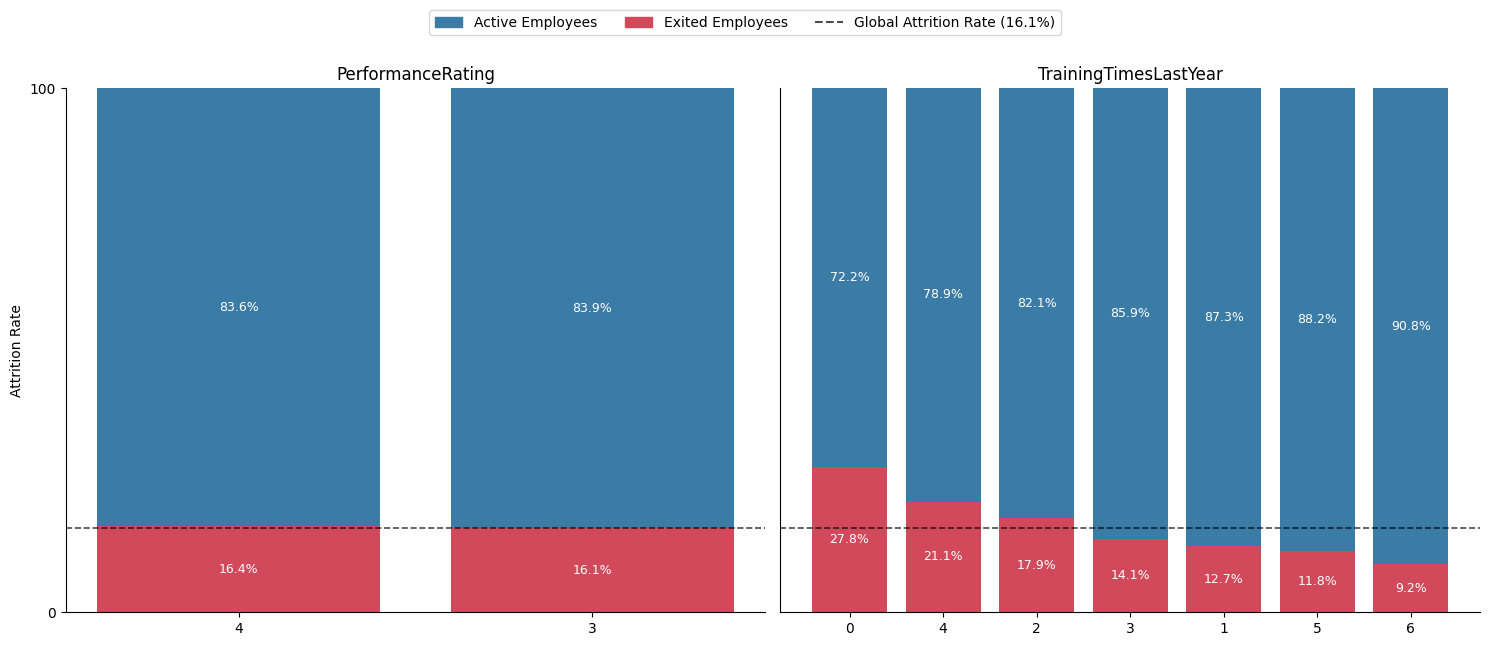

In [31]:
training_performance_cols = ['PerformanceRating', 'TrainingTimesLastYear']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, col in enumerate(training_performance_cols):
    ax = axes[i]

    # groupby Attrition
    temp = (
        df.groupby([col, 'AttritionLabel'])
          .size()
          .unstack(fill_value=0)
    )

    # Convert to percentage, sort descending by Exited Employees
    pct = temp.div(temp.sum(axis=1), axis=0) * 100
    pct = pct.sort_values(by='Exited Employees', ascending=False)

    x = range(len(pct))

    # Stacked barplot: Exited at bottom, Active at top
    bars_exited = ax.bar(
        x,
        pct['Exited Employees'],
        color=colors['Exited Employees'],
        label='Exited Employees'
    )
    bars_active = ax.bar(
        x,
        pct['Active Employees'],
        bottom=pct['Exited Employees'],
        color=colors['Active Employees'],
        label='Active Employees'
    )

    # Percentage annotations
    for j, (_, row) in enumerate(pct.iterrows()):
        exited_val = row['Exited Employees']
        active_val = row['Active Employees']

        if exited_val > 0:
            ax.text(
                j, exited_val / 2,
                f'{exited_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

        if active_val > 0:
            ax.text(
                j, exited_val + (active_val / 2),
                f'{active_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

    # Global attrition threshold line
    ax.axhline(
        y=16.1,
        color='black',
        linestyle='--',
        alpha=0.7,
        linewidth=1.2,
        label='Global Attrition Rate (16.1%)' if i == 1 else None
    )

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Axis formatting
    ax.set_title(col)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pct.index, rotation=0)
    ax.set_xlabel('')
    ax.set_ylim(0, 100)

    # Only show y-ticks once at the far left
    if i == 0:
        ax.set_yticks([0, 100])
        ax.set_ylabel('Attrition Rate')
    else:
        ax.set_yticks([0, 100])
        ax.tick_params(axis='y', left=False, labelleft=False)

# legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors['Active Employees']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Exited Employees']),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.7)
]
labels = [
    'Active Employees',
    'Exited Employees',
    'Global Attrition Rate (16.1%)'
]

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3
)

plt.tight_layout()
plt.show()

This section looks different from many of the earlier findings. `PerformanceRating` shows almost no visible gap between active employees and exited employees, but that should not be interpreted too quickly as proof that performance has no connection to attrition.

A closer look shows that ratings only take the values **3** and **4**, with no **1** or **2** anywhere in the distribution. This is a sign of a **compressed rating system**, or possible rating inflation, where most, if not all employees, are clustered into a narrow upper-middle range.

That matters because a compressed variable loses much of its analytical power. When almost everyone is rated as good, the feature cannot separate meaningful differences between employees, so any real relationship with attrition becomes difficult to detect. In that sense, the problem may be less about the performance itself and more about the limited quality of the measurement.

`TrainingTimesLastYear` does appear statistically significant, but the effect size is small and the pattern is not linear. Employees with no training show relatively high attrition (**27.8%**), but attrition is also elevated for those with **4 trainings** (**21.1%**), while groups with **5-6 trainings** are lower. A pattern like this is too uneven to support a simple conclusion that more training automatically reduces attrition.

Overall, this section suggests that **formal performance scoring is not a strong signal in this dataset**, while training may play a supporting role but still needs to be read together with tenure, role, and work conditions.

### **Summary**

Across the working condition section, the most consistent signals come from **overtime**, **business travel**, and **job involvement**, not from formal performance ratings.

This suggests that attrition is more closely tied to the **day-to-day work experience** than to formal evaluation outcomes. Employees do not appear to leave mainly because they are rated poorly. Instead, the pattern points more toward unsustainable work rhythm, heavy mobility demands, or weaker attachment to the job itself.

`PerformanceRating` contributes very little in this dataset, and the compressed distribution makes that result easier to understand. With so little variation, the variable is simply not very informative.

Taken together, the broader message is that attrition seems to grow more from how work is lived each day than from how performance is scored on paper.

---

## **Work Benefits and Perceived Value**

#### **1. Monthly Income**

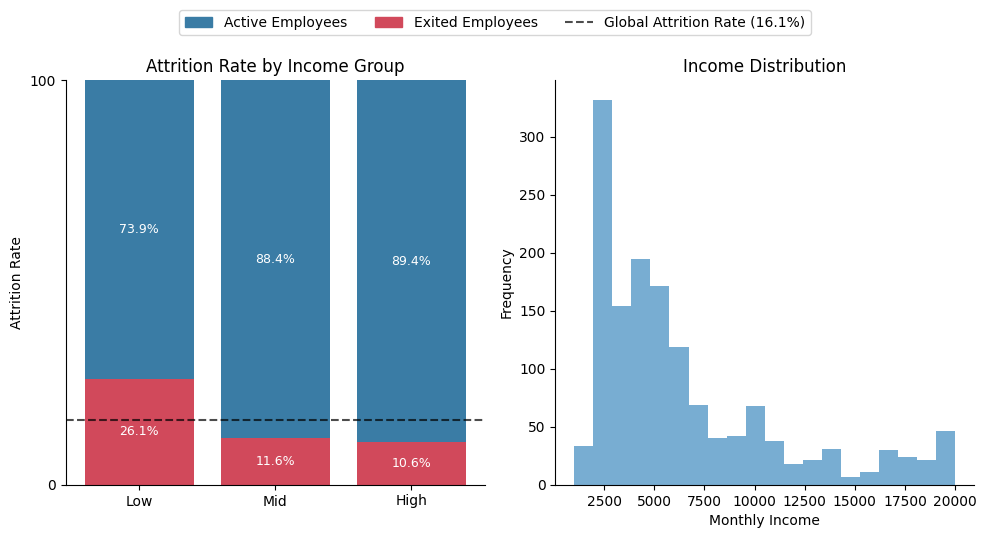

In [32]:
# Binning (3 groups)
df['IncomeGroup'] = pd.qcut(
    df['MonthlyIncome'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# =========================
# Plot 1: Attrition Rate
# =========================
ax = axes[0]

temp = (
    df.groupby(['IncomeGroup', 'AttritionLabel'])
      .size()
      .unstack(fill_value=0)
)

pct = temp.div(temp.sum(axis=1), axis=0) * 100
pct = pct.sort_values(by='Exited Employees', ascending=False)

x = range(len(pct))

# stacked bar
ax.bar(
    x,
    pct['Exited Employees'],
    color='#D1495B',
    label='Exited Employees'
)
ax.bar(
    x,
    pct['Active Employees'],
    bottom=pct['Exited Employees'],
    color='#3A7CA5',
    label='Active Employees'
)

# annotation
for j, (_, row) in enumerate(pct.iterrows()):
    exited_val = row['Exited Employees']
    active_val = row['Active Employees']

    if exited_val > 0:
        ax.text(j, exited_val/2, f'{exited_val:.1f}%', 
                ha='center', va='center', color='white', fontsize=9)
    if active_val > 0:
        ax.text(j, exited_val + active_val/2, f'{active_val:.1f}%',
                ha='center', va='center', color='white', fontsize=9)

# threshold line
ax.axhline(y=16.1, color='black', linestyle='--', alpha=0.7)

# formatting
ax.set_title('Attrition Rate by Income Group')
ax.set_xticks(list(x))
ax.set_xticklabels(pct.index)
ax.set_ylim(0, 100)
ax.set_yticks([0, 100])
ax.set_ylabel('Attrition Rate')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =========================
# Plot 2: Distribution (Context)
# =========================
ax = axes[1]

df['MonthlyIncome'].plot(
    kind='hist',
    bins=20,
    alpha=0.6,
    ax=ax
)

ax.set_title('Income Distribution')
ax.set_xlabel('Monthly Income')
ax.set_ylabel('Frequency')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# =========================
# Legend (global)
# =========================
handles = [
    plt.Rectangle((0, 0), 1, 1, color='#3A7CA5'),
    plt.Rectangle((0, 0), 1, 1, color='#D1495B'),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.7)
]
labels = [
    'Active Employees',
    'Exited Employees',
    'Global Attrition Rate (16.1%)'
]

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3
)

plt.tight_layout()
plt.show()

The gap across income groups is quite clear. Employees in the **Low** income group show attrition of about **26.1%**, while the **Mid** and **High** groups are much lower at around **11.6%** and **10.6%**. In this dataset, lower income is consistently associated with a higher chance of leaving.

The histogram adds important context. `MonthlyIncome` is right-skewed, which means a large share of employees is concentrated in the lower to middle income range, while very high-income employees are fewer. That makes the low-income pattern relevant not only in percentage terms, but also in terms of how many employees may be affected.

When connected to the earlier findings, lower income is also likely tied to **younger age, lower job level, and shorter tenure**. So compensation here should not be read as a fully separate issue. It seems to be part of a broader early-career vulnerability pattern.

#### **2. Compensation & Benefits**

In [33]:
# PercentSalaryHike derivative
df['SalaryHikeGroup'] = pd.qcut(
    df['PercentSalaryHike'],
    q=3,
    labels=['Low Hike', 'Mid Hike', 'High Hike']
)

# column variables
compben_cols = ['SalaryHikeGroup', 'StockOptionLevel']

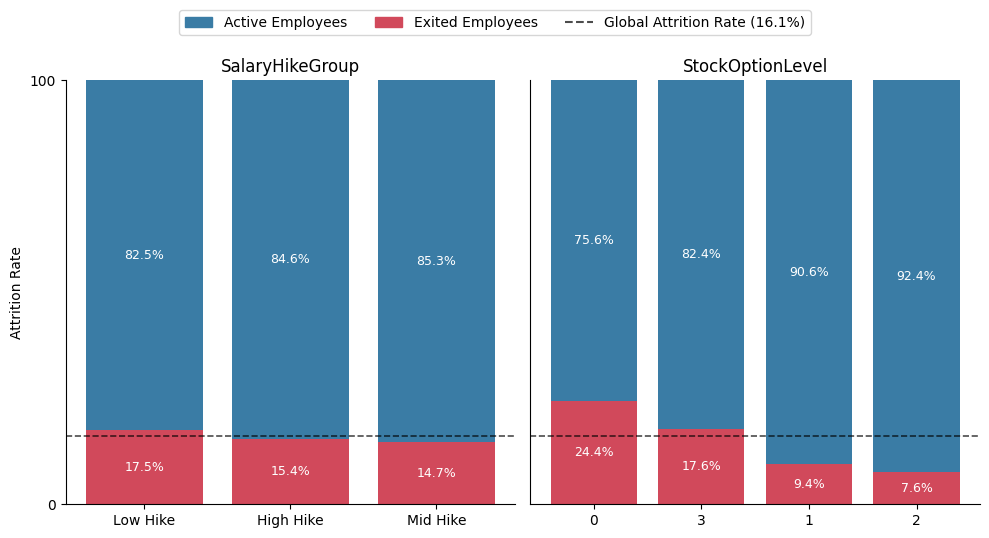

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, col in enumerate(compben_cols):
    ax = axes[i]

    # groupby Attrition
    temp = (
        df.groupby([col, 'AttritionLabel'])
          .size()
          .unstack(fill_value=0)
    )

    # Convert to percentage, sort descending by Exited Employees
    pct = temp.div(temp.sum(axis=1), axis=0) * 100
    pct = pct.sort_values(by='Exited Employees', ascending=False)

    x = range(len(pct))

    # Stacked barplot: Exited at bottom, Active at top
    ax.bar(
        x,
        pct['Exited Employees'],
        color=colors['Exited Employees'],
        label='Exited Employees'
    )
    ax.bar(
        x,
        pct['Active Employees'],
        bottom=pct['Exited Employees'],
        color=colors['Active Employees'],
        label='Active Employees'
    )

    # Percentage annotations
    for j, (_, row) in enumerate(pct.iterrows()):
        exited_val = row['Exited Employees']
        active_val = row['Active Employees']

        if exited_val > 0:
            ax.text(
                j, exited_val / 2,
                f'{exited_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

        if active_val > 0:
            ax.text(
                j, exited_val + (active_val / 2),
                f'{active_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=9
            )

    # Global attrition threshold line
    ax.axhline(
        y=16.1,
        color='black',
        linestyle='--',
        alpha=0.7,
        linewidth=1.2,
        label='Global Attrition Rate (16.1%)' if i == 2 else None
    )

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Axis formatting
    ax.set_title(col)
    ax.set_xticks(list(x))
    ax.set_xticklabels(pct.index, rotation=0)
    ax.set_xlabel('')
    ax.set_ylim(0, 100)

    # Only show y-ticks once at the far left
    if i == 0:
        ax.set_yticks([0, 100])
        ax.set_ylabel('Attrition Rate')
    else:
        ax.set_yticks([0, 100])
        ax.tick_params(axis='y', left=False, labelleft=False)

# legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors['Active Employees']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Exited Employees']),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.7)
]
labels = [
    'Active Employees',
    'Exited Employees',
    'Global Attrition Rate (16.1%)'
]

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=3
)

plt.tight_layout()
plt.show()

Within the benefits-related variables, `PercentSalaryHike` and `StockOptionLevel` behave quite differently.

`SalaryHikeGroup` looks fairly flat, with attrition staying around **14.7%-17.5%** across the categories. This matches the earlier statistical result, where `PercentSalaryHike` did not appear to be a strong differentiator. In other words, annual salary increase percentage does not seem to be one of the main retention levers in this dataset.

`StockOptionLevel` tells a more visible story. Employees with **StockOptionLevel 0** show attrition around **24.4%**, and the rate drops sharply at level **1** (**9.4%**) and level **2** (**7.6%**). Level **3** rises again to **17.6%**, which creates a more complicated pattern.

Rather than reading that last point at face value, it is worth checking the composition more carefully before drawing a conclusion.

In [35]:
pd.crosstab(df['StockOptionLevel'], df['AttritionLabel'])

AttritionLabel,Active Employees,Exited Employees
StockOptionLevel,,
0,477,154
1,540,56
2,146,12
3,70,15


In [36]:
pd.crosstab(df['StockOptionLevel'], df['IncomeGroup'])

IncomeGroup,Low,Mid,High
StockOptionLevel,,,
0,230,201,200
1,184,192,220
2,42,72,44
3,34,25,26


In [37]:
pd.crosstab(df['StockOptionLevel'], df['JobRole'])

JobRole,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
StockOptionLevel,,,,,,,,,
0,51,24,108,37,59,33,136,139,44
1,59,21,110,57,60,31,104,125,29
2,13,3,21,5,20,11,34,44,7
3,8,4,20,3,6,5,18,18,3


In [38]:
pd.crosstab(df['StockOptionLevel'], df['TenureGroup'])

TenureGroup,<=1 year,2-3 years,4-5 years,6-10 years,10+ years
StockOptionLevel,,,,,
0,113,114,131,173,100
1,70,102,124,186,114
2,18,22,31,69,18
3,14,17,20,20,14


As it happens, the relatively higher attrition at `StockOptionLevel 3` does not automatically mean the benefit is ineffective. That group is much smaller than the lower levels, so it is more vulnerable to distortion from its composition, such as a concentration of specific roles or tenure stages.

In addition, long-term benefits like stock options may not carry the same retention meaning for employees who are still in an early stage of company attachment. If the employee has not yet developed a stronger long-term commitment, the presence of a higher stock option level may not fully offset other pressures.

A safer interpretation is to compare employees who have stock options with those who do not. From that view, the more consistent pattern is that the **absence of stock options** is associated with higher attrition, while differences between the higher stock-option levels should be read more cautiously.

#### **3. Employee Review**

In [39]:
satisfaction_cols = [
    'EnvironmentSatisfaction', 'JobSatisfaction',
    'RelationshipSatisfaction', 'WorkLifeBalance'
    ]

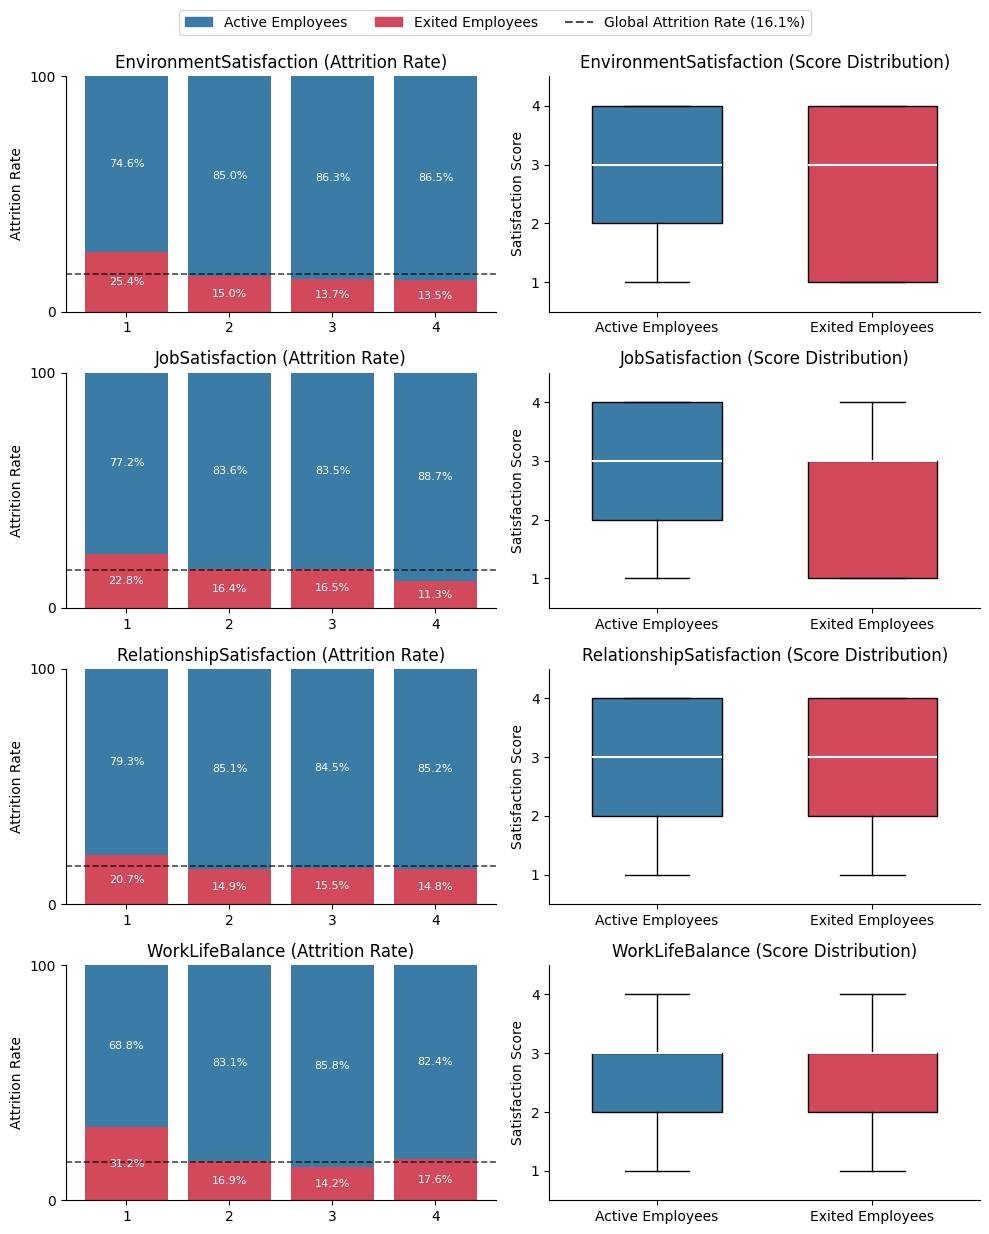

In [40]:
fig, axes = plt.subplots(4, 2, figsize=(10, 12))

for i, col in enumerate(satisfaction_cols):
    ax_rate = axes[i, 0]
    ax_box = axes[i, 1]

    # ==========================================
    # LEFT: Attrition Rate by Satisfaction Score
    # ==========================================
    temp = (
        df.groupby([col, 'AttritionLabel'])
          .size()
          .unstack(fill_value=0)
    )

    pct = temp.div(temp.sum(axis=1), axis=0) * 100
    pct = pct.sort_index()   # keep ordinal order: 1,2,3,4

    x = range(len(pct))

    ax_rate.bar(
        x,
        pct['Exited Employees'],
        color=colors['Exited Employees']
    )
    ax_rate.bar(
        x,
        pct['Active Employees'],
        bottom=pct['Exited Employees'],
        color=colors['Active Employees']
    )

    # annotate percentage
    for j, (_, row) in enumerate(pct.iterrows()):
        exited_val = row['Exited Employees']
        active_val = row['Active Employees']

        if exited_val > 0:
            ax_rate.text(
                j, exited_val / 2,
                f'{exited_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=8
            )

        if active_val > 0:
            ax_rate.text(
                j, exited_val + (active_val / 2),
                f'{active_val:.1f}%',
                ha='center', va='center',
                color='white', fontsize=8
            )

    ax_rate.axhline(
        y=16.1,
        color='black',
        linestyle='--',
        alpha=0.7,
        linewidth=1.2
    )

    ax_rate.set_title(f'{col} (Attrition Rate)')
    ax_rate.set_xticks(list(x))
    ax_rate.set_xticklabels(pct.index)
    ax_rate.set_ylim(0, 100)

    # semua subplot kiri punya ticks & label
    ax_rate.set_yticks([0, 100])
    ax_rate.set_ylabel('Attrition Rate')

    ax_rate.spines['top'].set_visible(False)
    ax_rate.spines['right'].set_visible(False)

    # ==========================================
    # RIGHT: Satisfaction Score Distribution
    # ==========================================
    box_data = [
        df.loc[df['AttritionLabel'] == 'Active Employees', col].dropna(),
        df.loc[df['AttritionLabel'] == 'Exited Employees', col].dropna()
    ]

    bp = ax_box.boxplot(
        box_data,
        patch_artist=True,
        labels=['Active Employees', 'Exited Employees'],
        widths=0.6
    )

    # color each box
    bp['boxes'][0].set(facecolor=colors['Active Employees'])
    bp['boxes'][1].set(facecolor=colors['Exited Employees'])

    # style lines
    for median in bp['medians']:
        median.set(color='white', linewidth=1.5)

    for whisker in bp['whiskers']:
        whisker.set(color='black', linewidth=1)

    for cap in bp['caps']:
        cap.set(color='black', linewidth=1)

    for flier in bp['fliers']:
        flier.set(marker='o', markersize=4, alpha=0.5, markeredgecolor='gray')

    ax_box.set_title(f'{col} (Score Distribution)')
    ax_box.set_xlabel('')
    ax_box.set_ylabel('Satisfaction Score')
    ax_box.set_ylim(0.5, 4.5)
    ax_box.set_yticks([1, 2, 3, 4])

    ax_box.spines['top'].set_visible(False)
    ax_box.spines['right'].set_visible(False)

# global legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors['Active Employees']),
    plt.Rectangle((0, 0), 1, 1, color=colors['Exited Employees']),
    plt.Line2D([0], [0], color='black', linestyle='--', alpha=0.7)
]
labels = [
    'Active Employees',
    'Exited Employees',
    'Global Attrition Rate (16.1%)'
]

fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    ncol=3
)

plt.tight_layout()
plt.show()

The employee review variables show a fairly consistent direction: employees who left tend to report lower work experience scores, even though the distributions still overlap with those of active employees.

On the attrition-rate side, score **1** is repeatedly the highest-risk group. `EnvironmentSatisfaction` at score 1 reaches about **25.4%**, `JobSatisfaction` at score 1 is around **22.8%**, and the clearest signal appears in `WorkLifeBalance`, where score 1 reaches about **31.2%**. `RelationshipSatisfaction` moves in a similar direction, but the gap is less pronounced and was not statistically significant earlier.

The boxplots support the same reading. In general, the score distributions for **Exited Employees** sit slightly lower than those for **Active Employees**, especially for `EnvironmentSatisfaction`, `JobSatisfaction`, and `WorkLifeBalance`. Even when the medians are similar, the overall spread still suggests that employees who left tended to experience work somewhat less positively.

### **Summary**

From the compensation side, attrition is most visible among employees with lower income and no stock options. From the work-experience side, the risk also rises when work-life balance, environment satisfaction, and job satisfaction are low.

What stands out is that `PerformanceRating` and `PercentSalaryHike` do not do much to separate employees who leave from those who stay.

Taken together, this points to a consistent pattern: employees appear more likely to leave when compensation feels less attractive, long-term value is less visible, and the everyday work experience feels tiring or unrewarding.

Because of that, a retention response cannot focus on only one side. The company likely needs both a stronger compensation value story and a better day-to-day employee experience, especially for the groups that are already more vulnerable.

---
# **Executive Summary**
---

This analysis shows that employee attrition in the dataset does not happen randomly. It is concentrated in certain employee profiles and working conditions. The overall attrition rate is **16.1%**, which means the company is losing around **1 in 6 employees**. Over time, the recorded exits also become more concentrated toward the end of the observation period, which suggests that attrition pressure may not have been stable.

When the pattern is broken down further, the most vulnerable employees tend to be in an **early-career stage**: younger, single, lower in job level, lower in income, and shorter in tenure. The risk becomes even clearer in roles such as *Sales Representative*, *Laboratory Technician*, and *Human Resources*, and under more demanding work conditions such as **overtime**, **frequent business travel**, and **low job involvement**.

At the same time, attrition in this dataset is not strongly separated by `PerformanceRating`, gender, or formal education level. This leads to a fairly clear conclusion: the company does not appear to be facing a broad performance problem. Instead, attrition seems more closely related to a combination of **role pressure, early-tenure vulnerability, compensation value, and everyday work experience**.

## **Key Findings**

1. **Attrition is most concentrated in the early-career stage.**  
   Employees aged **18-25**, employees who are **single**, and employees with **very short tenure** show the highest attrition rates. This makes the first stage of employment especially important for retention planning.

2. **Role structure and workload matter more than formal performance scores.**  
   Variables such as `OverTime`, `JobRole`, `BusinessTravel`, and `JobInvolvement` stand out much more clearly than `PerformanceRating`. The pattern suggests that employees are not mainly leaving because they perform poorly, but because the job context feels heavier or less sustainable.

3. **Some roles carry much higher attrition risk than others.**  
   *Sales Representative*, *Laboratory Technician*, and *Human Resources* show the highest attrition, while more senior roles such as *Manager* and *Research Director* remain much lower. This shows that retention pressure is uneven across positions.

4. **Compensation value matters, but not mainly through annual salary hike percentage.**  
   Lower-income employees and employees without stock options show higher attrition. In contrast, `PercentSalaryHike` adds limited separation. This suggests that employees may respond more to the overall value proposition than to routine annual increase percentages alone.

5. **Work-life balance and job satisfaction can function as early warning signals.**  
   Lower scores in `WorkLifeBalance`, `EnvironmentSatisfaction`, and `JobSatisfaction` appear more often among employees who leave. These variables may not explain everything on their own, but they are useful signals that employee experience may already be deteriorating.

## **Business Recommendation**

1. **Prioritize retention efforts during the first 1-3 years of employment.**  
   Since attrition is most concentrated among newer and early-career employees, the company should strengthen onboarding, early coaching, buddy support, and structured check-ins during the first 3, 6, and 12 months. The goal is not only to keep employees active, but to help them feel that the role fits and that a future inside the company is visible.

2. **Audit the highest-risk roles, not just the broad departments.**  
   HR should focus more closely on roles such as *Sales Representative*, *Laboratory Technician*, and *Human Resources*. The review can look at workload, target pressure, manager quality, career path clarity, and the most common reasons behind resignation in those roles.

3. **Reduce chronic overtime and unnecessary mobility strain.**  
   Since `OverTime` and `BusinessTravel` show strong associations with attrition, the company should review work rhythm in higher-risk teams. That may include workload redistribution, healthier scheduling, limits on repeated overtime, and more realistic travel expectations.

4. **Strengthen perceived value for lower-income and lower-level employees.**  
   Employees with lower income and no stock options show higher attrition risk. In response, the company may need a combination of better early-stage compensation review, targeted retention benefits for high-risk roles, clearer promotion pathways, and stronger communication around the full reward package.

5. **Use employee review scores as an early warning system.**  
   Lower scores in work-life balance, environment satisfaction, job satisfaction, and job involvement can be monitored as early signals, especially when they appear together with high overtime and short tenure. This creates a chance for HR to intervene before attrition turns into actual exit.